In [235]:
#setup

#conda create --name sds-project python=3.12
#conda install --channel conda-forge pandas numpy matplotlib requests geopandas
#conda install --channel conda-forge ipykernel, jenkspy


import pandas as pd
import requests
import geopandas as gpd
import folium
import numpy as np
import jenkspy
from datetime import datetime
import matplotlib.pyplot as plt
import os
import webbrowser


In [236]:
MAP_KEY = '5eae605403f5deded880b550afef3667'

def get_transaction_count() :
  count = 0
  try:
    response = requests.get(url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + MAP_KEY)
    data = response.json()
    df = pd.Series(data)
    count = df['current_transactions']
  except:
    print ("Error in our call.")
  return count

In [237]:
#sensors:
da_url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + MAP_KEY + '/all'
daterange_df = pd.read_csv(da_url)
daterange_df['min_date'] = pd.to_datetime(daterange_df['min_date'], format = '%Y-%m-%d')
daterange_df['max_date'] = pd.to_datetime(daterange_df['max_date'], format = '%Y-%m-%d')

display(daterange_df)

#set one sensor
#sensor = daterange_df["data_id"][2] #VIIRS has better resolution than other sensors (375m vs 1000m), NRT means only a few minutes lag
daterange_df.info()

,data_id,min_date,max_date
0,MODIS_NRT,2026-02-01,2026-05-12
1,MODIS_SP,2000-11-01,2026-01-31
2,VIIRS_NOAA20_NRT,2026-03-01,2026-05-12
3,VIIRS_NOAA20_SP,2018-04-01,2026-02-28
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-12
5,VIIRS_SNPP_NRT,2026-03-01,2026-05-12
6,VIIRS_SNPP_SP,2012-01-20,2026-02-28
7,LANDSAT_NRT,2022-06-20,2026-05-11
8,GOES_NRT,2022-08-09,2026-05-12
9,BA_MODIS,2000-11-01,2026-02-01


<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   data_id   11 non-null     str           
 1   min_date  11 non-null     datetime64[us]
 2   max_date  11 non-null     datetime64[us]
dtypes: datetime64[us](2), str(1)
memory usage: 396.0 bytes


In [238]:
#dict to map continent names to bounding boxes
continents_bounding_boxes = {
    "africa": "-20,-37.5,52,37.5",
    "antarctica": "-180,-90,180,-60",
    "asia": "25,-10,180,82",
    "europe": "-31.5,34,66,82",
    "north america": "-170,7,-52,84",
    "south america": "-82,-56,-34,13",
    "australia": "113,-44,154,-10",
    "oceania": "110,-50,180,-10",
    "world": "-180,-90,180,90"
}

#evaluate if the input is a name or a bbox and return bbox
def get_continent_bbox(continent_name):
    # First check if the input is already a coordinate string
    if isinstance(continent_name, str) and ',' in continent_name:
        parts = continent_name.split(',')
        if len(parts) == 4:
            try:
                # Validate that all parts are numbers
                [float(x) for x in parts]
                return continent_name  # Return as-is if valid coordinates
            except ValueError:
                pass  # Not valid coordinates, proceed to continent check

    # If not coordinates, treat as continent name
    standardized_name = continent_name.strip().lower()
    bbox = continents_bounding_boxes.get(standardized_name)
    if bbox is None:
        print('No Bounding box could be matched to your input.')
    return bbox 

In [239]:
#retrieve data 

#user input for area
userdefined_area = 'world'
enddate = '2025-05-01'

#parameters for API call
area = get_continent_bbox(userdefined_area) #either "world" or bbox lonmin,latmin,lonmax,latmax, e. g. 0,35,25,70 for europe, "-20,-37.5,52,37.5"  for africa
day_range = 1 #in range(1,5)
if enddate is None:
    enddate = datetime.now() #get todays date
else:
    enddate = pd.to_datetime(enddate, format = '%Y-%m-%d')


#set sensor parameter based on enddate
#MODIS_NRT where available
#else: MODIS_SP
#error if neither of them is available
mindate_NRT = daterange_df['min_date'][daterange_df['data_id'] == 'VIIRS_NOAA20_NRT'].values[0]
mindate_SP = daterange_df['min_date'][daterange_df['data_id'] == 'VIIRS_NOAA20_SP'].values[0]
mindate_modis = daterange_df['min_date'][daterange_df['data_id'] == 'MODIS_SP'].values[0]



request_data = True #flag to prevent data request for invalid enddate

#set sensor based on enddate
if enddate > mindate_NRT:
    sensor = 'VIIRS_NOAA20_NRT'
    print('The displayed data is non-processed and not of science quality.')
elif enddate >= mindate_SP:
    sensor = 'VIIRS_NOAA20_SP'
elif enddate >= mindate_modis:
    sensor = 'MODIS_SP'
else:
    print(f"Out of date range, please select an end date after {mindate_modis}")
    request_data = False


print("Current sensor name: ", sensor)

#data request
if request_data:
    area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + f'/{sensor}/{area}/{day_range}/' + enddate.strftime(format = '%Y-%m-%d')
    start_count = get_transaction_count()
    df_area = pd.read_csv(area_url)
    end_count = get_transaction_count()
    print ('We used %i transactions.' % (end_count-start_count))
    display(df_area.head())
    display(df_area.shape)

Current sensor name:  VIIRS_NOAA20_SP
We used 36 transactions.


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,65.65537,143.41673,326.78,0.39,0.59,2025-05-01,42,N20,VIIRS,n,2,271.79,1.79,D,0
1,66.23586,143.37500,333.97,0.36,0.58,2025-05-01,42,N20,VIIRS,n,2,276.27,2.33,D,0
2,67.10489,135.69037,327.09,0.44,0.62,2025-05-01,43,N20,VIIRS,n,2,277.15,4.78,D,0
3,67.10828,135.67831,326.63,0.44,0.62,2025-05-01,43,N20,VIIRS,n,2,277.34,2.68,D,0
4,67.11493,135.67229,328.73,0.44,0.62,2025-05-01,43,N20,VIIRS,n,2,278.55,2.68,D,0


(28144, 15)

In [240]:
#clean df_area:

if sensor == 'MODIS_SP':
    mask = df_area['confidence'] < 30
else:
    mask = df_area['confidence'] != "l"

#remove low confidence entries
print(mask.sum(), "Entries removed due to low confidence")
df_area = df_area[mask]

#format datetime
df_area["acq_datetime"] = pd.to_datetime(df_area['acq_date'] + df_area['acq_time'].astype(str).str.zfill(4),  # Zero-pad to 4 digits (e.g., '626' -> '0626')
    format='%Y-%m-%d%H%M', errors='coerce'
)

df_area = df_area.drop(columns = ["acq_date", "acq_time"])

25458 Entries removed due to low confidence


In [241]:
area_gpd = gpd.GeoDataFrame(
    df_area, geometry=gpd.points_from_xy(df_area["longitude"], df_area["latitude"], crs = 4326)
)

vmin = df_area['frp'].quantile(0.02)
vmax = df_area['frp'].quantile(0.98)

#area_gpd.explore(column = "frp", cmap = "YlOrRd", vmin = vmin, vmax = vmax)

area_gpd_sub = area_gpd[['latitude', 'longitude', 'frp', 'acq_datetime', 'geometry']]
area_gpd_sub['acq_datetime'] = area_gpd_sub['acq_datetime'].astype(str)



## intersect fire data with countries
- count number of fires per country

In [242]:
#load countries geopandas and spatially join with fire
countries_simple = gpd.read_file('data/countries_simple.gpkg').to_crs(4326)
fire_countries_merged = area_gpd_sub.sjoin(countries_simple, how = 'left', predicate = 'within')
fire_countries_merged.head()

,latitude,longitude,frp,acq_datetime,geometry,index_right,CountryName
0,65.65537,143.41673,1.79,2025-05-01 00:42:00,POINT (143.41673 65.65537),140.0,Russia
1,66.23586,143.37500,2.33,2025-05-01 00:42:00,POINT (143.375 66.23586),140.0,Russia
2,67.10489,135.69037,4.78,2025-05-01 00:43:00,POINT (135.69037 67.10489),140.0,Russia
3,67.10828,135.67831,2.68,2025-05-01 00:43:00,POINT (135.67831 67.10828),140.0,Russia
4,67.11493,135.67229,2.68,2025-05-01 00:43:00,POINT (135.67229 67.11493),140.0,Russia


In [243]:
print(len(area_gpd_sub)- fire_countries_merged.groupby('CountryName')['frp'].count().sum(), "fires were not matched to a country") #some fires are not matched to a country. probably due to polygon simplification

296 fires were not matched to a country


In [244]:
#count number of fires by country

#group fire occurences by country and count
fire_countries_count = pd.DataFrame(fire_countries_merged.groupby('CountryName')['frp'].count()) #take any random column for the count, here 'frp'
fire_countries_count = fire_countries_count.rename(columns= {'frp': 'firecount'}) #rename column to count

#merge with countries_simple so it is a gpd and calculate fire density
fire_countries_count = pd.merge(countries_simple, fire_countries_count, how = 'left', on = 'CountryName')
fire_countries_count['area_km2'] = (fire_countries_count.geometry.to_crs(8857).area / 10**6).round(1) #mind the crs conversion to equal area!
fire_countries_count['fires/100\'000km2'] = (fire_countries_count['firecount']/fire_countries_count['area_km2']*100000).round(3)
display(fire_countries_count.head())

,CountryName,geometry,firecount,area_km2,fires/100'000km2
0,Afghanistan,"MULTIPOLYGON (((74.87679 37.2749, 74.88489 37....",5.0,641718.1,0.779
1,United Kingdom,"MULTIPOLYGON (((33.013 34.64377, 33.00785 34.5...",56.0,251619.5,22.256
2,Albania,"MULTIPOLYGON (((20.07889 42.55579, 20.16519 42...",2.0,28709.7,6.966
3,Algeria,"MULTIPOLYGON (((8.64195 36.94096, 8.65373 36.9...",141.0,2306853.2,6.112
4,United States,"MULTIPOLYGON (((-168.15542 -14.51823, -168.165...",708.0,9495212.8,7.456


Text(0, 0.5, 'FRP')

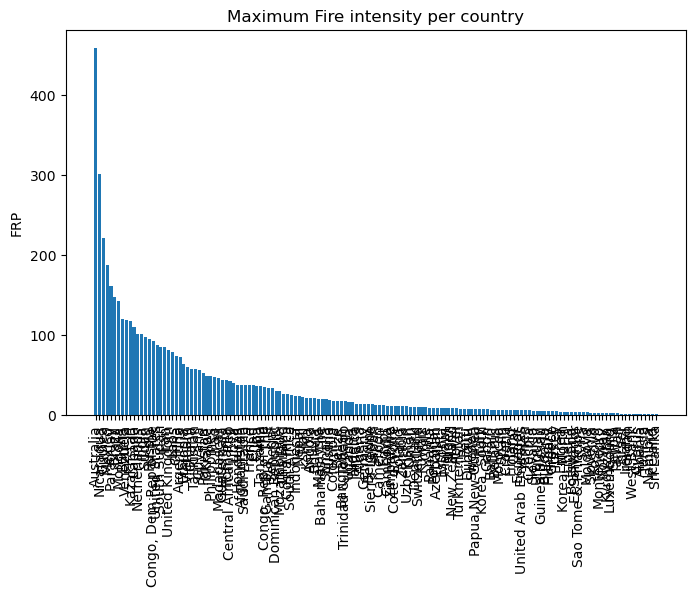

In [245]:
#find most intense fire per country
fire_countries_max = pd.DataFrame(fire_countries_merged.groupby('CountryName')['frp'].max())
fire_countries_max = fire_countries_max.rename(columns= {'frp': 'max_frp'}) #rename column to max
fire_countries_max.head()
fire_countries_max = fire_countries_max.sort_values('max_frp', ascending= False)
fig, ax = plt.subplots(figsize=(8,5))
plt.xticks(rotation = 90)
ax.bar(fire_countries_max.index, fire_countries_max['max_frp'])
ax.set_title('Maximum Fire intensity per country')
ax.set_ylabel('FRP')


In [246]:
#fire_countries_count.explore(column = "fires/100'000km2")

## visualise

In [247]:
"""
# Initialize the basemap centered on Zurich
m4 = folium.Map(tiles="CartoDB Positron")

# Add the layer with a custom marker parameter
#marker from the font awesom library ('fa')
folium.GeoJson(
    area_gpd_sub,
    name="Wildfires",
    tooltip=folium.GeoJsonTooltip(fields=["frp"], aliases=["Fire Reactive Power:"]),
    # Override the default teardrop with a blue bicycle icon
    marker=folium.Marker(  # <- THIS IS NEW
        icon=folium.Icon(color="red", icon="fire", prefix="fa", icon_color= "orange")
    ),
).add_to(m4)


#add fire density choropleth
folium.Choropleth(
geo_data=fire_countries_count,
name="Fire Density (Fires/100'000km2)",
data=fire_countries_count,
columns=["CountryName", "fires/100'000km2"],
key_on="feature.properties.CountryName",
fill_color="viridis",
fill_opacity=0.6,
line_opacity=0.2,
legend_name="Fires per 100'000km2"
).add_to(m4)


# Add the interactive layer control menu
folium.LayerControl().add_to(m4)
m4
"""

'\n# Initialize the basemap centered on Zurich\nm4 = folium.Map(tiles="CartoDB Positron")\n\n# Add the layer with a custom marker parameter\n#marker from the font awesom library (\'fa\')\nfolium.GeoJson(\n    area_gpd_sub,\n    name="Wildfires",\n    tooltip=folium.GeoJsonTooltip(fields=["frp"], aliases=["Fire Reactive Power:"]),\n    # Override the default teardrop with a blue bicycle icon\n    marker=folium.Marker(  # <- THIS IS NEW\n        icon=folium.Icon(color="red", icon="fire", prefix="fa", icon_color= "orange")\n    ),\n).add_to(m4)\n\n\n#add fire density choropleth\nfolium.Choropleth(\ngeo_data=fire_countries_count,\nname="Fire Density (Fires/100\'000km2)",\ndata=fire_countries_count,\ncolumns=["CountryName", "fires/100\'000km2"],\nkey_on="feature.properties.CountryName",\nfill_color="viridis",\nfill_opacity=0.6,\nline_opacity=0.2,\nlegend_name="Fires per 100\'000km2"\n).add_to(m4)\n\n\n# Add the interactive layer control menu\nfolium.LayerControl().add_to(m4)\nm4\n'

In [248]:
from folium.plugins import MarkerCluster


#define mapcenter based on selected continent
lonmin,latmin,lonmax,latmax = map(float, area.split(','))
mapcenter = [(latmin+latmax)/2, (lonmin+lonmax)/2]

# Initialize the basemap
m6 = folium.Map(tiles="CartoDB Positron", zoom_start = 3, location = mapcenter)

# Add the bboxrectangle to the map
folium.Rectangle(
    bounds=[[latmin, lonmin], [latmax, lonmax]],  # [[south, west], [north, east]]
    color='blue',
    fill=False,
    weight=2,
    popup = "Selected Area"
).add_to(m6)

"""
#add hover over single icons
folium.GeoJson(
    area_gpd_sub,
    name="Individual wildfires",
    show = False, #default off
    tooltip=folium.GeoJsonTooltip(fields=["frp"], aliases=["Fire Reactive Power:"]),
    # Override the default teardrop with a blue bicycle icon
    marker=folium.Marker(  # <- THIS IS NEW
        icon=folium.Icon(color="red", icon="fire", prefix="fa", icon_color= "orange")
    ),
).add_to(m6)
"""

#############################################
#add clusters
marker_cluster = MarkerCluster(name="Scaled Wildfire Clusters", cmap = "YlOrRd").add_to(m6)

for idx, row in area_gpd_sub.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    frp = row["frp"]
    tooltip_text = f"Fire Reactive Power: {frp}"

    # Mathematical Scaling Logic:
    # Base size of 14px, plus an increase based on the square root of the frp
    icon_size = 12 + (np.sqrt(frp) * 30)  # <- THIS IS NEW

    # Injecting custom CSS to draw a perfect circle with our dynamic size (NEW)
    icon_html = f"""

        <div style="
            font-size: {icon_size}px;
            color: #FF4500;
            background: #FF8C00;
            border-radius: 50%;
            width: {icon_size}px;
            height: {icon_size}px;
            display: flex;
            align-items: center;
            justify-content: center;
            border: 1px solid #1f77b4;">
            <i class="fa fa-fire"></i>
        </div>"""


    # Apply the custom HTML using DivIcon
    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(  # <- THIS IS NEW
            html=icon_html,
            icon_size=(icon_size, icon_size),
            icon_anchor=(icon_size / 2, icon_size / 2),  # Centers the icon perfectly
        ),
        tooltip=tooltip_text,
    ).add_to(marker_cluster)


######################################

#fire density choropleth


#check if there is more than one country with fires in it, otherwise the choropleth does not work
if fire_countries_count['fires/100\'000km2'].count() > 1:    
    #add fire density choropleth
    vmin = fire_countries_count["fires/100'000km2"].quantile(0.05)
    vmax = fire_countries_count["fires/100'000km2"].quantile(0.8)

    # Clone the dataframe and clip values
    #otherwise the vmin and vmax don't work and the colorbar is affected by outliers
    data_clipped = fire_countries_count.copy()
    data_clipped["fires/100'000km2"] = data_clipped["fires/100'000km2"].clip(lower=vmin, upper=vmax)

    folium.Choropleth(
    geo_data=fire_countries_count,
    name="Fire Density (Fires/100'000km2)",
    data=data_clipped,
    columns=["CountryName", "fires/100'000km2"],
    key_on="feature.properties.CountryName",
    fill_color="YlOrRd",
    fill_opacity=0.6,
    line_opacity=0.2,
    legend_name="Fires per 100'000km2",
    vmin = vmin,
    vmax = vmax, 
    nan_fill_color= 'white', 
    bins = 10,
    use_jenks= fire_countries_count['fires/100\'000km2'].count() > 10 #only use jenks if more classes than bins
    ).add_to(m6)

#######################################
#add invisible density choropleth hover over feature
folium.GeoJson(
    fire_countries_count,
    name="Interactive Tooltips",
    # Make the polygons completely transparent so they do not hide the choropleth colors
    style_function=lambda x: {"fillColor": "#ffffff00", "color": "#ffffff00"},
    tooltip=folium.GeoJsonTooltip(
        fields=["CountryName", "fires/100'000km2"],
        aliases=["Country:", "Fire Density:"],
        localize=True,
    ),
).add_to(m6)

##################################3
# Add the interactive layer control menu
folium.LayerControl().add_to(m6)



#add title to map and save it as html file

# Add a title using folium.Element
title_html = f'''
             <h3 align="center" style="font-size:16px"><b>Wildfires in selected area on {enddate.strftime(format = '%Y-%m-%d')}</b></h3>
             '''

m6.get_root().html.add_child(folium.Element(title_html))

#create legend for the blue rectangle bbox
# Create HTML for the legend
legend_html = '''
<div style="position: fixed; 
     bottom: 10px; right: 10px; width: 150px; height: 70px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:16px; padding: 5px">
     
    <p style="margin: 0 0 5px 0;"><b>Legend</b></p>
    
    <p style="margin: 5px 0;">
        <svg width="20" height="20" style="vertical-align: middle;">
            <rect x="2" y="2" width="16" height="16" 
                  fill="none" stroke="blue" stroke-width="2"/>
        </svg>
        Selected Area
    </p>
</div>
'''
# Add the legend to the map
m6.get_root().html.add_child(folium.Element(legend_html))



file_path = 'docs/index.html'
m6.save(file_path)

#define boundaries of displayed map
m6.fit_bounds([(latmin, lonmin),(latmax, lonmax)])  # [(latmin, lonmin), (latmax, lonmax)]

#m6

In [249]:
webbrowser.open_new_tab(f'file://{os.path.realpath(file_path)}')

True